# Self Organizing Maps --Som


In [1]:
import matplotlib.pyplot as plt
from minisom import MiniSom
from keras.datasets import mnist
import numpy as np

In [2]:

np.random.RandomState(18)
N_points = 40
N_neurons = N_points*2
t = np.linspace(0,np.pi*2,N_points)
x = np.cos(t) + (np.random.rand(N_points) - .5)*0.3
y = np.sin(t) + (np.random.rand(N_points) - .5)*0.3

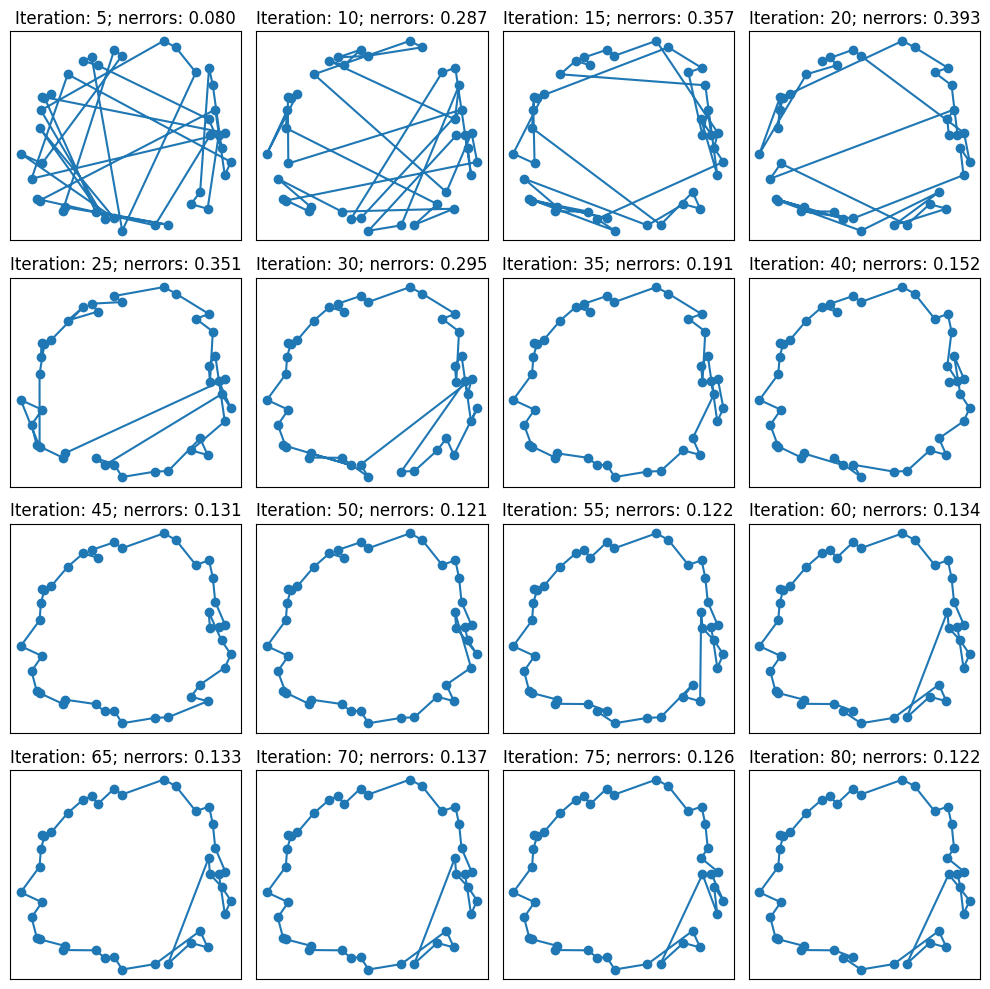

In [5]:
# minisom(som-width, som-height, input_len, sigma, learning_rate,neighborhood_function='triangle', activation_distance='euclidean',topology='rectangular')
# Initialize and train the SOM
som = MiniSom( 
              1, 
              N_neurons,  
              2, # input_len
              sigma=8,
             learning_rate=0.4,
             neighborhood_function='gaussian',
             random_seed=0
)

points = np.array([x,y]).T
som.random_weights_init(points)

plt.figure(figsize=(10,10))

for i , iteration in enumerate(range(5,81,5)):
    som.train(points, iteration, verbose=False,random_order=False)
    plt.subplot(4,4,i+1)
    plt.scatter(x,y)
    visit_order = np.argsort([som.winner(p)[1] for p in points])
    visit_order = np.concatenate((visit_order, [visit_order[0]]))
    plt.plot(points[visit_order][:,0], points[visit_order][:,1])
    plt.title(f'Iteration: {iteration}; nerrors: {som.quantization_error(points):.3f}')
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()

